In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/heart.csv')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


cp = cheast pain level of the patient

trestbps = blood pressure level at the resting condition

chol = cholestral level at admission at hospital

fbsc= fasting blood suger level of the patient

restecg = ECG(electrocardiographic) level at the resting condition

thalach = maximum heart rate achived during the test.

exang = exercise induce angina(facing any dicomfort or not)

oldpeak = how much ecg changing during exercise from resting

slope = slope of the ecg

ca(coronary artery) = the number of major blood vessels coloured by fluroscopy

thal(thalassemia) = a blood disorder that can damage your heart

target = a patient is having a heart disease or not,1 for yes and 0 is no

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

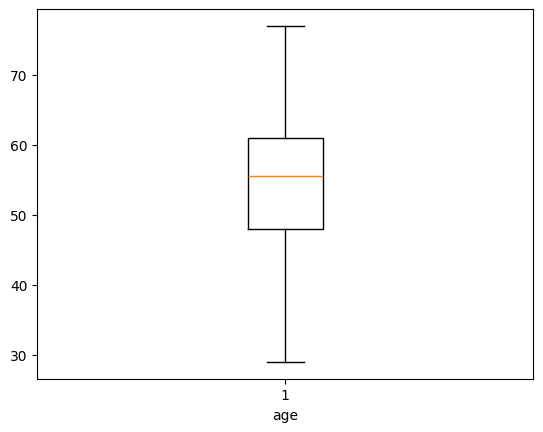

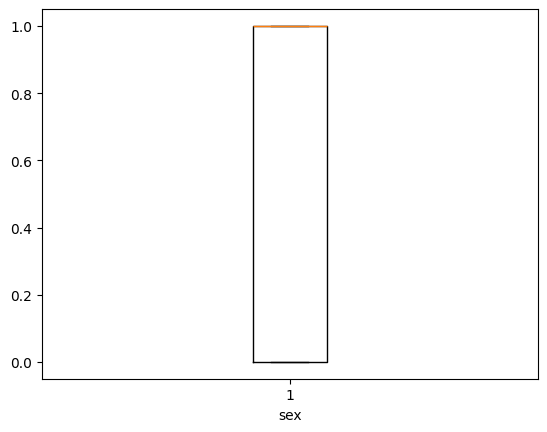

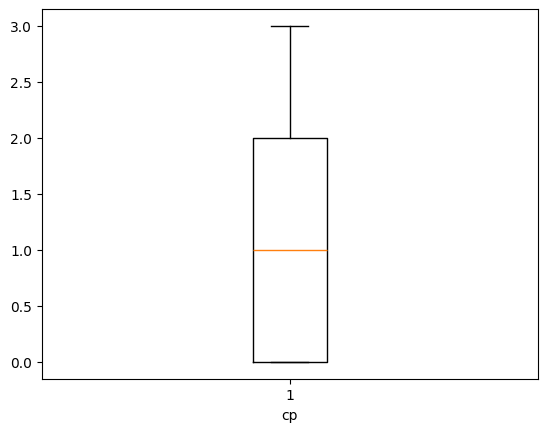

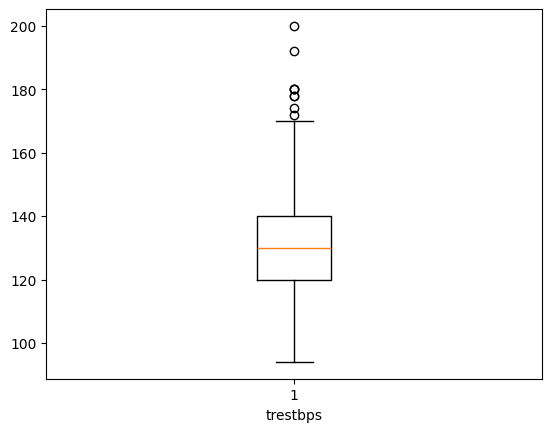

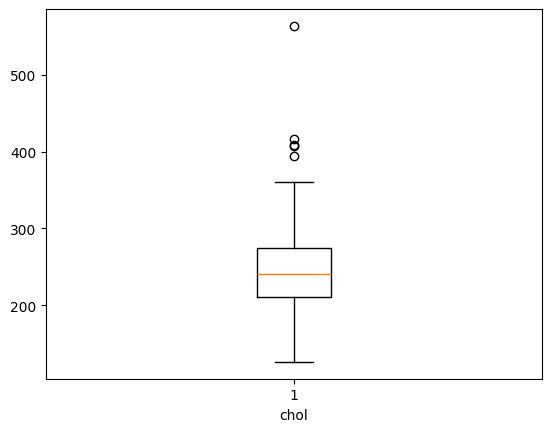

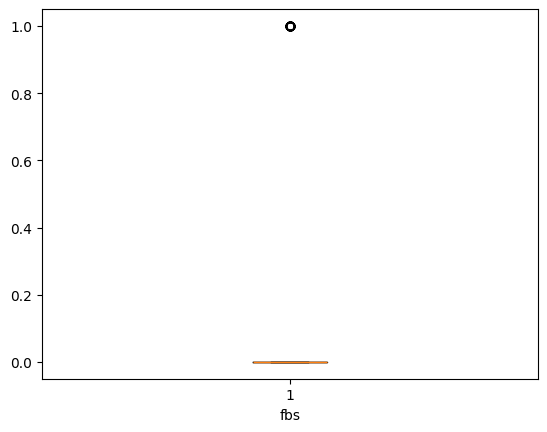

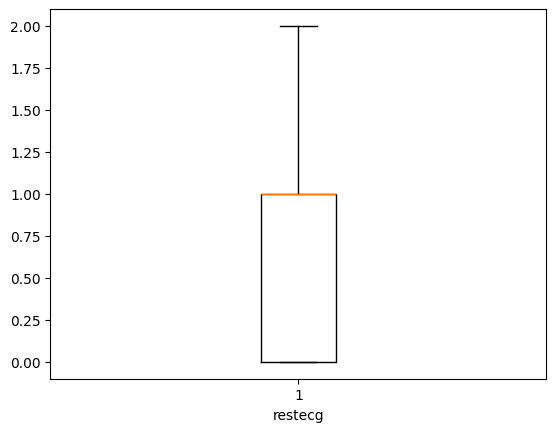

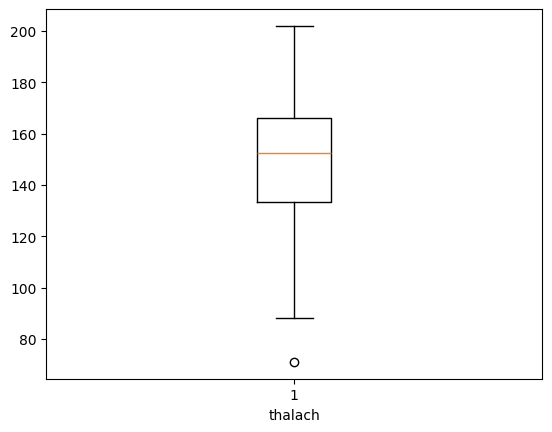

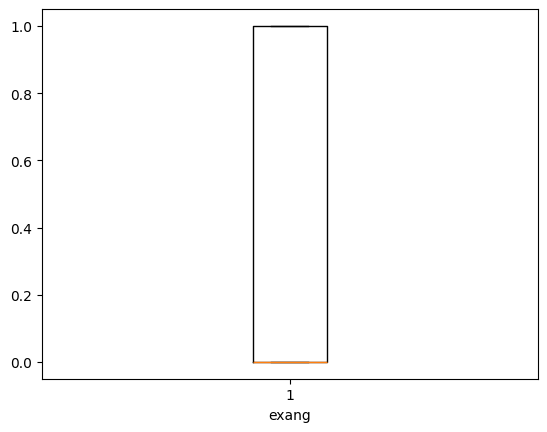

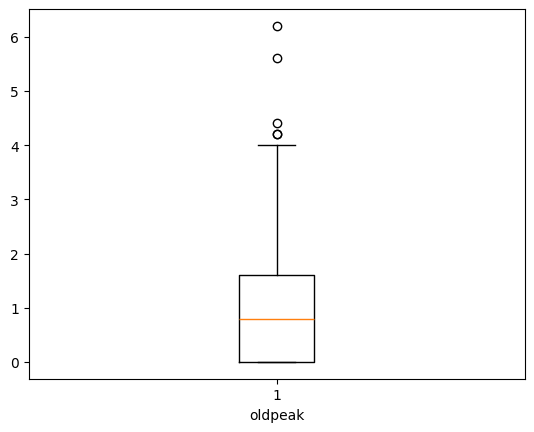

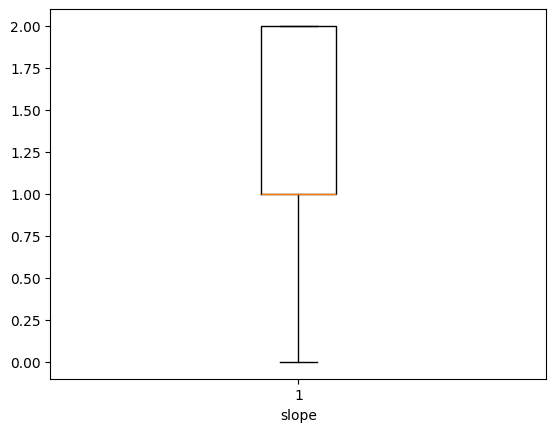

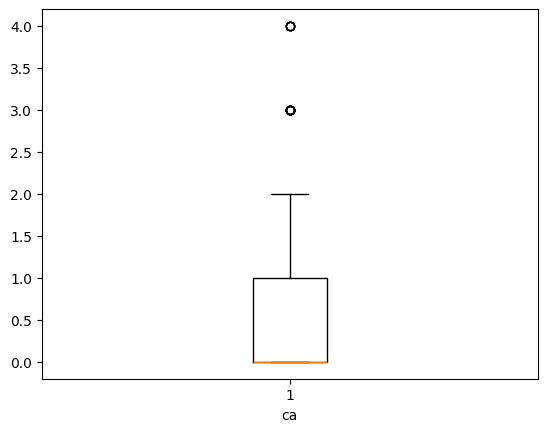

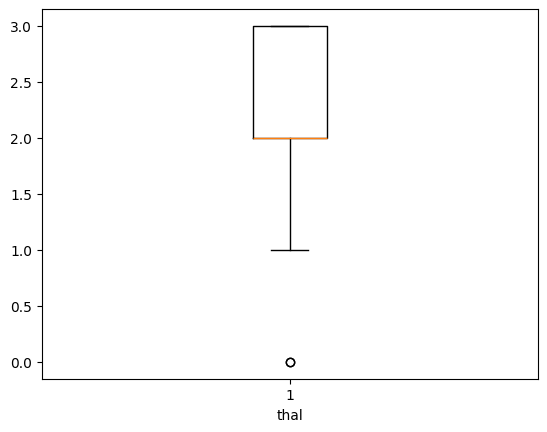

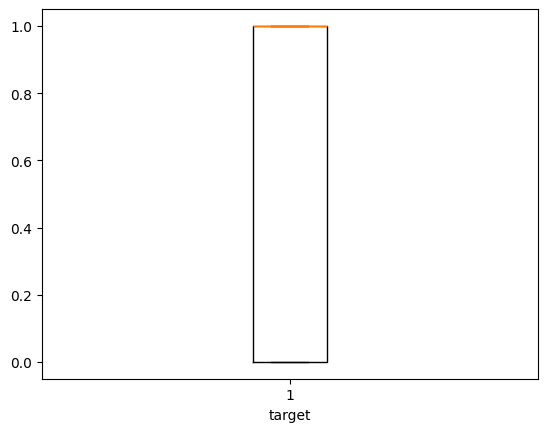

In [ ]:
for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
723,1
733,1
739,0
843,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt.predict(x_test)

In [ ]:
new_df = pd.DataFrame()
new_df['actual'] = y_test
new_df['predicted'] = y_pred

In [ ]:
new_df

,actual,predicted
245,1,1
349,0,1
135,0,0
389,1,0
66,1,1
...,...,...
402,1,0
123,1,1
739,0,0
274,1,0


In [ ]:
from sklearn.metrics import*

In [ ]:
accuracy_score(y_test,y_pred)

0.7213114754098361

In [ ]:
confusion_matrix(y_test,y_pred)

array([[25,  7],
       [10, 19]])

In [ ]:
from sklearn import tree

In [ ]:
dt.get_depth()

9

In [ ]:
tree.plot_tree(dt,fontsize=7)

In [ ]:
depths =[1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
  dt = DecisionTreeClassifier(max_depth=i,random_state=42)
  dt.fit(x_train,y_train)
  y_pred = dt.predict(x_test)
  acc = accuracy_score(y_test,y_pred)
  print(f'max depth is {i} accuracy score is {acc}')

max depth is 1 accuracy score is 0.7049180327868853
max depth is 2 accuracy score is 0.6885245901639344
max depth is 3 accuracy score is 0.7540983606557377
max depth is 4 accuracy score is 0.7377049180327869
max depth is 5 accuracy score is 0.7377049180327869
max depth is 6 accuracy score is 0.7049180327868853
max depth is 7 accuracy score is 0.7213114754098361
max depth is 8 accuracy score is 0.7377049180327869
max depth is 9 accuracy score is 0.7377049180327869
max depth is 10 accuracy score is 0.7377049180327869
max depth is 11 accuracy score is 0.7377049180327869
max depth is 12 accuracy score is 0.7377049180327869
max depth is 13 accuracy score is 0.7377049180327869
